In [1]:
import numpy as np
import matplotlib.pyplot as plt

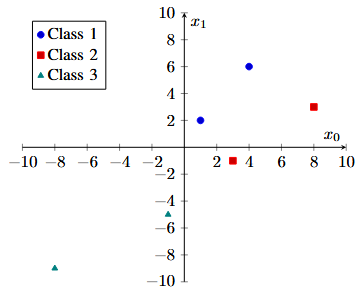

A classification problem is formed by three classes. A set of 2-dimensional data $X = [x_1 x_2 x_3 x_4 x_5 x_6]$ is given:
$$
X = 
\begin{bmatrix}
1 & 4 & 8 & 3 & −1 & −8 \\
2 & 6 & 3 & −1 & −5 & −9
\end{bmatrix}
$$
each belonging to one of the three classes, as indicated in the class label vector $l = [l_1 \; l_2 \;  l_3 \; l_4 \; l_5 \; l_6]$:
$$
l = \begin{bmatrix}1 & 1 & 2 & 2 & 3 & 3\end{bmatrix}
$$

Use Fisher’s Discriminant Analysis to:

## 1) Calculate the two-class projection vector w ∈ R2 obtained by the data points associated with class 1 and class 2.

In [59]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]] += 1
        ms[t[n]] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

def LDA_scatter_matrix(X, t):
    m = X.mean(axis=0)
    means = class_means(X, t)
    # for i, mean in enumerate(means):
    #     print(f"Mean for class {i+1}:\n", mean)

    K = len(means)
    N = len(X)

    # https://stackoverflow.com/questions/28663856/how-do-i-count-the-occurrence-of-a-certain-item-in-an-ndarray
    unique, counts = np.unique(t, return_counts=True)
    Ns = dict(zip(unique, counts))
    
    S_W = 0
    S_B = 0
    for k in range(K):
        S_B += Ns[k] * np.outer(means[k] - m, means[k] - m)
        
        for n in range(N):
            if t[n] == k:
                S_W += (X[n] - means[k])[:, np.newaxis] @ (X[n] - means[k])[:, np.newaxis].T
    
    return S_B, S_W

def projection_matrix(X, t, D_prime=1):
    S_B, S_W = LDA_scatter_matrix(X, t)
    # print("S_B:\n", S_B)
    # print("S_W:\n", S_W)
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, sorted_indices]
    W = eigvecs[:, :D_prime]
    return W

In [60]:
X = np.array([  [1, 4, 8, 3, -1, -8],
                [2, 6, 3, -1, -5, -9]])
l = np.array([1, 1, 2, 2, 3, 3])

w = projection_matrix(X[:,:4].T, l[:4]-1)
print(f"w = \n{w}")

w = 
[[ 0.69614584]
 [-0.71790039]]


## 2) Draw in Figure 1 the two-class projection vector w calculated in question 1.

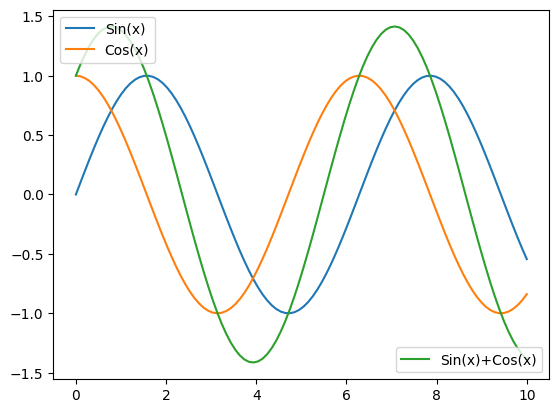

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) + np.cos(x)

# Plot the data
line1, = plt.plot(x, y1, label='Sin(x)')
line2, = plt.plot(x, y2, label='Cos(x)')
line3, = plt.plot(x, y3, label='Sin(x)+Cos(x)')

# Create the first legend
legend1 = plt.legend([line1, line2], ['Sin(x)', 'Cos(x)'], loc='upper left')

# Add the first legend to the axis
plt.gca().add_artist(legend1)

# Create the second legend
legend2 = plt.legend([line3], ['Sin(x)+Cos(x)'], loc='lower right')

# Show the plot
plt.show()

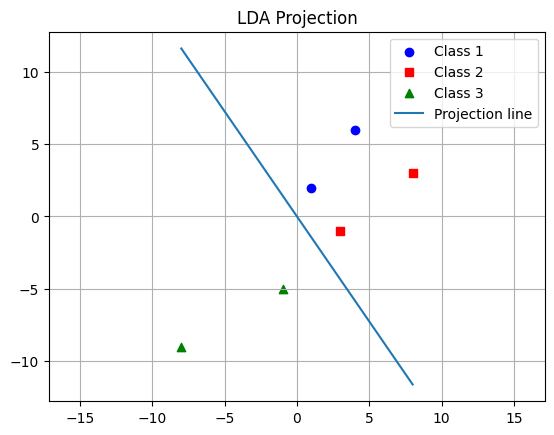

In [97]:
def plot_lda(X, t, w, colors=['b', 'r', 'g'], markers=['o', 's', '^']):
    plt.title("LDA Projection")
    plt.axis('equal')
    plt.grid()
    
    labels = np.unique(t)
    for i, label in enumerate(labels):
        plt.scatter(*X[:, t == label], label=f'Class {label}', color=colors[i], marker=markers[i])
    n = np.linspace(np.min(X[0])/w[0], np.max(X[0])/w[0], 100)
    plt.plot(n*w[0], n*w[1], label='Projection line')

    plt.legend()

plot_lda(X, l, w)

## 3) Can the data points from all three classes be classified correctly using the two-class projection vector? Why/Why not?

No, they cannot since the projection line cannot differentiate between class 2 and 3, seeing as they are both close to perpendicular on the projection line.

## 4) Calculate the 1-dimensional three-class projection vector w ∈ R2 obtained from all the data points.

In [81]:
w = projection_matrix(X.T, l-1)
print(f"w = \n{w}")

w = 
[[ 0.5671532 ]
 [-0.82361232]]


## 5) Draw in Figure 1 the three-class projection vector w calculated in question 4.

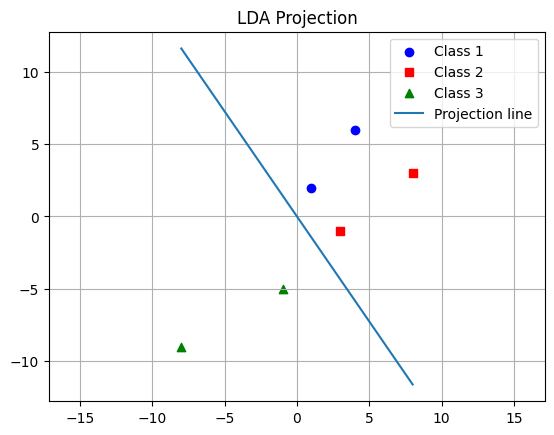

In [82]:
plot_lda(X, l, w)

## 6) Can the data points from all three classes be classified correctly using the three-class projection vector? Why/Why not?

This projection vector is better since it is no longer as perpendicular on both class 2 and 3, but as those classes are so in line with eachother, there will always be quite a bit of overlap between the probability of it being either one.